In [40]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

df = pd.read_csv('netflix_titles.csv')
df.columns.size #counts colums
len(df) #number of rows
df.shape # rows, columns
df.shape[0] #index 0-rows, 1-columns
df.info()
df.dtypes #shows data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Q5

In [41]:
# Check whether the dataset contains missing values.
df.isnull().sum() #per column
df.isnull().sum().sum() #aggregated null
df['duration'].isnull().sum() #how many null values in a column

np.int64(3)

Step 4 — Data Cleaning

In [45]:
df = df.dropna()
df.isnull().sum()
df['director'] = df['director'].fillna('Unknown')

Step 5 — Basic Analysis

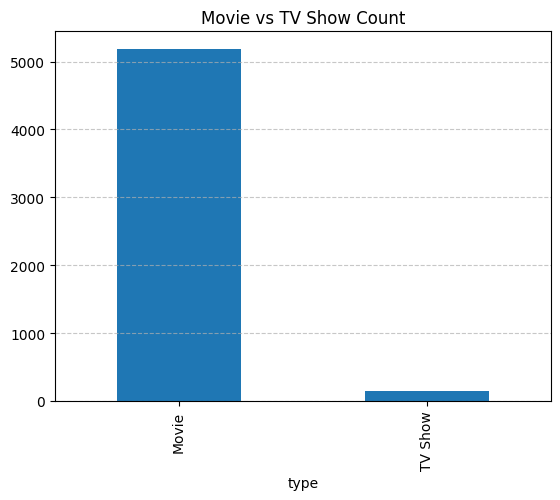

In [88]:
# Movies vs TV Shows
df['type'].value_counts()

#bar graph
df['type'].value_counts().plot(kind = 'bar')
plt.title('Movie vs TV Show Count')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

# saving
plt.savefig('movies_vs_tv_shows_count.png', dpi=300)
plt.show()

In [58]:
# Top 10 Countries Producing Netflix Content
print(f'{df['country'].value_counts().sort_values(ascending = False).head(10)}')

country
United States     1846
India              875
United Kingdom     183
Canada             107
Spain               91
Egypt               90
Nigeria             88
Japan               83
Turkey              79
Indonesia           76
Name: count, dtype: int64


In [64]:
# Most Common Genres
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        336
Stand-Up Comedy                                     286
Comedies, Dramas, International Movies              257
Dramas, Independent Movies, International Movies    243
Children & Family Movies, Comedies                  179
Dramas, International Movies, Romantic Movies       160
Documentaries                                       156
Comedies, International Movies                      152
Comedies, International Movies, Romantic Movies     143
Dramas                                              133
Name: count, dtype: int64

In [66]:
# Content Growth Over Time
df['release_year'].value_counts().sort_index()

release_year
1942      1
1944      1
1945      1
1946      1
1947      1
       ... 
2017    657
2018    648
2019    519
2020    442
2021    161
Name: count, Length: 72, dtype: int64

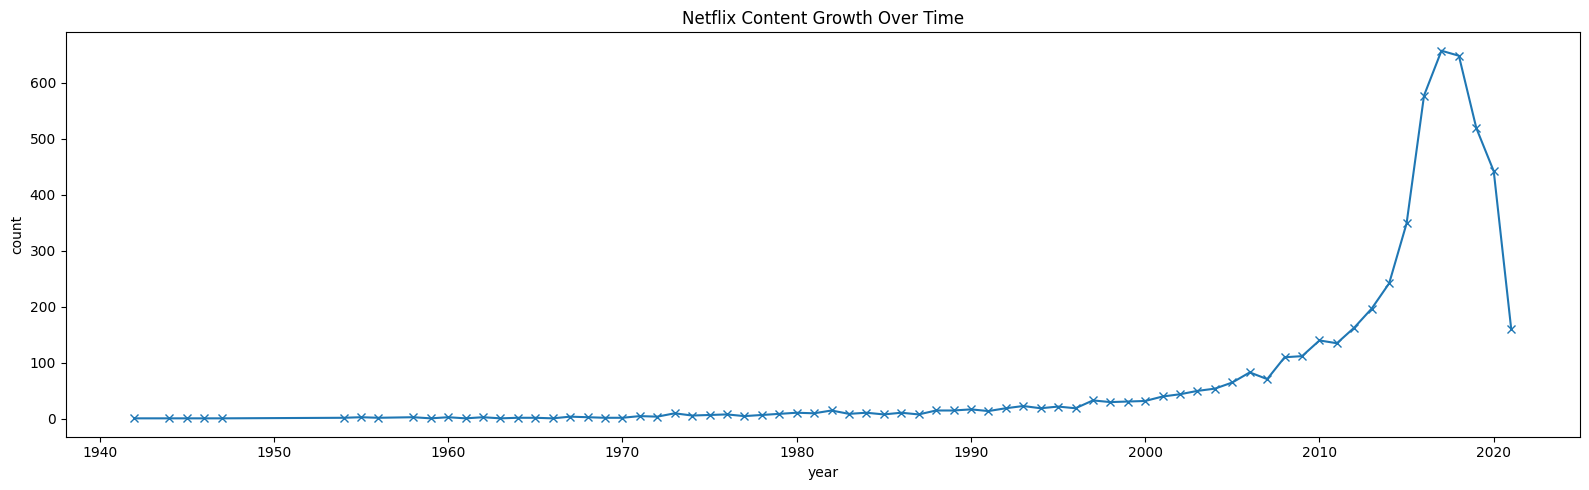

In [87]:
#content growth visualisation
plt.figure(figsize=(16,5))
df['release_year'].value_counts().sort_index().plot(marker = 'x', markersize = 6) #can use ms as well for markersize
plt.ylabel('count')
plt.xlabel('year')
plt.title('Netflix Content Growth Over Time')
plt.tight_layout()

#save chart
plt.savefig('content_growth.png', dpi = 300)
plt.show()

QUESTIONS

Q1

In [83]:
# Which country produces the most Netflix content?
df['country'].value_counts().head(1)

country
United States    1846
Name: count, dtype: int64

Q2

In [84]:
# Are there more movies or TV shows?
df['type'].value_counts()

type
Movie      5185
TV Show     147
Name: count, dtype: int64

Q3

In [85]:
# Which genres are most common?
df['listed_in'].value_counts().head(1)

listed_in
Dramas, International Movies    336
Name: count, dtype: int64